<a href="https://colab.research.google.com/github/qaiserfatmi/Dengue/blob/main/Dengue_ML_Analysis_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Analysis for Dengue from following published Paper**

Iqbal NT, Ahmed K, Khalid A, Imtiaz
K, Ali QM, Munir T, et al. (2025) Clinical
characteristics and serotype association of
dengue and dengue like illness in Pakistan.
PLoS Negl Trop Dis 19(5): e0012978. https://
doi.org/10.1371/journal.pntd.0012978

**Step 1 — Install and import required packages**

In [3]:
!pip install -q xgboost openpyxl mlxtend shap umap-learn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.metrics import silhouette_score

from xgboost import XGBClassifier, XGBRegressor

import shap
import warnings
warnings.filterwarnings("ignore")

**Step 2 — Upload the Excel file**

In [5]:
# Use if you want to Browse File from computer

#from google.colab import files
#uploaded = files.upload()

In [6]:
# Use if you want to directly Read the Excel file from Google colab, after uploading in content folder.

url = "https://journals.plos.org/plosntds/article/file?type=supplementary&id=10.1371/journal.pntd.0012978.s006"
df = pd.read_excel(url)
df.head()

# df = pd.read_excel("/content/journal.pntd.0012978.s006.xlsx")


,N#,Year,Aim,UWARN Sample ID,Inpatient/ Outpatient,Days of Illness,Age,Gender,Clinician I Diagnosis,Clinician II Diagnosis,...,Diarrhea,Heavy menstrual bleed,Blood in stool,Blood in urine,cough,Gum bleeding,Rash,Platelet transfusion,eGFR,Days of Hospitalization
0,0,2.0,1.0,B1-D01-21028-EDT,Outpatient,6.0,27.0,Female,Zika virus infection,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,No,0.0
1,1,2.0,1.0,B1-D01-11001-EDT,Inpatient,9.0,44.0,Female,Dengue fever,Dengue with warning signs,...,No,Yes,No,No,No,No,No,No,>60,4.0
2,2,2.0,1.0,B1-D01-11002-EDT,Inpatient,7.0,46.0,Female,Dengue fever,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,>60,2.0
3,3,2.0,1.0,B1-D01-11003-EDT,Inpatient,4.0,12.0,Female,Dengue fever,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,No,2.0
4,4,2.0,1.0,B1-D01-21001-EDT,Outpatient,5.0,40.0,Male,Acute Viral fever,Dengue with warning signs,...,No,No,No,No,No,No,No,No,>60,0.0


**Step 3 — Check dataset size, sheets, and columns**

In [7]:
df.shape

(352, 78)

In [8]:
df.head()

,N#,Year,Aim,UWARN Sample ID,Inpatient/ Outpatient,Days of Illness,Age,Gender,Clinician I Diagnosis,Clinician II Diagnosis,...,Diarrhea,Heavy menstrual bleed,Blood in stool,Blood in urine,cough,Gum bleeding,Rash,Platelet transfusion,eGFR,Days of Hospitalization
0,0,2.0,1.0,B1-D01-21028-EDT,Outpatient,6.0,27.0,Female,Zika virus infection,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,No,0.0
1,1,2.0,1.0,B1-D01-11001-EDT,Inpatient,9.0,44.0,Female,Dengue fever,Dengue with warning signs,...,No,Yes,No,No,No,No,No,No,>60,4.0
2,2,2.0,1.0,B1-D01-11002-EDT,Inpatient,7.0,46.0,Female,Dengue fever,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,>60,2.0
3,3,2.0,1.0,B1-D01-11003-EDT,Inpatient,4.0,12.0,Female,Dengue fever,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,No,2.0
4,4,2.0,1.0,B1-D01-21001-EDT,Outpatient,5.0,40.0,Male,Acute Viral fever,Dengue with warning signs,...,No,No,No,No,No,No,No,No,>60,0.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 78 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   N#                                    350 non-null    object        
 1   Year                                  349 non-null    float64       
 2   Aim                                   349 non-null    float64       
 3   UWARN Sample ID                       349 non-null    object        
 4   Inpatient/ Outpatient                 349 non-null    object        
 5   Days of Illness                       318 non-null    float64       
 6   Age                                   349 non-null    float64       
 7   Gender                                349 non-null    object        
 8   Clinician I Diagnosis                 340 non-null    object        
 9   Clinician II Diagnosis                349 non-null    object        
 10  Fi

In [10]:
df.columns.tolist()

['N#',
 'Year ',
 'Aim',
 'UWARN Sample ID',
 'Inpatient/ Outpatient',
 'Days of Illness',
 'Age ',
 'Gender',
 'Clinician I Diagnosis',
 'Clinician II Diagnosis',
 'Final Diagnosis',
 'Sample Collection Date  (DD/MM/YYYY)',
 'Final Dx (Peter)',
 'Peter Diagnosis',
 'NS-1 antigen',
 'IgM Antibody',
 'DENV Dx Results',
 'RNaseP PCR',
 'RNaseP Cq Value',
 'DENV PCR ',
 'DENV Cq Value',
 'ZIKV PCR ',
 'ZIKV Cq Value',
 'DENV Serotype',
 'DV1',
 'DV2',
 'DV3',
 'DV4',
 ' Fever or chills ',
 'Days of Fever',
 'Fever or chills onset date',
 'Currently symptomatic?',
 'Fever or chills resolution date',
 'Weight Kg',
 'Systolic Blood Pressure',
 'Diastolic Blood Pressure',
 'Pulse',
 'Temperature (c)',
 'Respiratory rate',
 'Pulse oxygen %',
 'Hemotocrit (%)',
 'WBC_count (10^9/L)',
 'Lymph_count (%)',
 'Neut_count  (%)',
 'Hemoglobin (g/dl)',
 'Platelet        (10^9/L)',
 'Thrombocytopenia Grade',
 'NLR',
 'ALT (IU/L)',
 'AST (IU/L)',
 'BUN  (mg/dl)',
 'Creatinine     (mg/dl)',
 'BACTERIA',
 

**Step 4 — Clean column names**

In [11]:
# Store original names for comparison
original_columns = df.columns.tolist()

# Clean column names
df.columns = (
    df.columns
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", "_", regex=True)
    .str.replace(r"[^\w]", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
)

# Check whether cleaning created duplicate names
duplicates = df.columns[df.columns.duplicated()].tolist()

print("Cleaned columns:")
print(df.columns.tolist())

print("\nDuplicate columns:")
print(duplicates)

Cleaned columns:
['n', 'year', 'aim', 'uwarn_sample_id', 'inpatient_outpatient', 'days_of_illness', 'age', 'gender', 'clinician_i_diagnosis', 'clinician_ii_diagnosis', 'final_diagnosis', 'sample_collection_date_dd_mm_yyyy', 'final_dx_peter', 'peter_diagnosis', 'ns_1_antigen', 'igm_antibody', 'denv_dx_results', 'rnasep_pcr', 'rnasep_cq_value', 'denv_pcr', 'denv_cq_value', 'zikv_pcr', 'zikv_cq_value', 'denv_serotype', 'dv1', 'dv2', 'dv3', 'dv4', 'fever_or_chills', 'days_of_fever', 'fever_or_chills_onset_date', 'currently_symptomatic', 'fever_or_chills_resolution_date', 'weight_kg', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'pulse', 'temperature_c', 'respiratory_rate', 'pulse_oxygen', 'hemotocrit', 'wbc_count_10_9_l', 'lymph_count', 'neut_count', 'hemoglobin_g_dl', 'platelet_10_9_l', 'thrombocytopenia_grade', 'nlr', 'alt_iu_l', 'ast_iu_l', 'bun_mg_dl', 'creatinine_mg_dl', 'bacteria', 'alt_class', 'ast_class', 'population_density', 'humidity', 'hospitalization', 'hypertension'

**Step 5 — Inspect important diagnostic columns**

In [12]:
for col in df.columns:
    if any(keyword in col.lower() for keyword in [
        "pcr", "ns", "igm", "igg", "diagnosis",
        "serotype", "hospital", "severity", "dengue"
    ]):
        print("\nCOLUMN:", col)
        print(df[col].value_counts(dropna=False).head(20))
        print("-" * 70)


COLUMN: clinician_i_diagnosis
clinician_i_diagnosis
Dengue fever                                                            247
Fever                                                                    30
NaN                                                                      12
Viral Fever                                                               6
Viral fever                                                               5
Suspected Dengue fever                                                    4
Dengue like illness                                                       3
Enteric fever                                                             2
URTI                                                                      2
Upper respiratory tract infection                                         2
Suspected Dengue                                                          2
Acute Gastroenteritis                                                     2
Suspected EBV reactivation         

**Step 6 — Select the correct DENV PCR column**

In [13]:
pcr_col = "denv_pcr"

df[pcr_col].value_counts(dropna=False)

,count
denv_pcr,
Positive,203
Negative,80
NaN,69


**Step 7 — Convert DENV PCR result into binary target**

In [14]:
def convert_pcr_result(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()

    if x in ["positive", "pos", "+", "1", "1.0", "yes", "detected"]:
        return 1

    if x in ["negative", "neg", "-", "0", "0.0", "no", "not detected"]:
        return 0

    return np.nan

df["PCR_positive"] = df[pcr_col].apply(convert_pcr_result)

df["PCR_positive"].value_counts(dropna=False)

,count
PCR_positive,
1.0,203
0.0,80
NaN,69


**Step 8 — Keep only PCR-tested patients**

In [15]:
df_pcr = df.dropna(subset=["PCR_positive"]).copy()
df_pcr["PCR_positive"] = df_pcr["PCR_positive"].astype(int)

df_pcr["PCR_positive"].value_counts()

,count
PCR_positive,
1,203
0,80


**Step 9 — Remove diagnostic leakage columns**

In [16]:
# This is the most important scientific correction. When predicting PCR positivity, do not include variables that directly reveal diagnosis.

leakage_keywords = [
    "pcr", "cq", "ct", "serotype", "denv",
    "diagnosis", "dx", "ns_1", "ns1", "igm", "igg",
    "final", "positive", "negative", "rnasep", "zikv",
    "dv1", "dv2", "dv3", "dv4"
]

leakage_cols = [
    col for col in df_pcr.columns
    if any(keyword in col.lower() for keyword in leakage_keywords)
]

leakage_cols

['clinician_i_diagnosis',
 'clinician_ii_diagnosis',
 'final_diagnosis',
 'sample_collection_date_dd_mm_yyyy',
 'final_dx_peter',
 'peter_diagnosis',
 'ns_1_antigen',
 'igm_antibody',
 'denv_dx_results',
 'rnasep_pcr',
 'rnasep_cq_value',
 'denv_pcr',
 'denv_cq_value',
 'zikv_pcr',
 'zikv_cq_value',
 'denv_serotype',
 'dv1',
 'dv2',
 'dv3',
 'dv4',
 'bacteria',
 'PCR_positive']

In [17]:
# Create features and target:

X = df_pcr.drop(columns=leakage_cols, errors="ignore")
y = df_pcr["PCR_positive"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (283, 57)
y shape: (283,)
PCR_positive
1    203
0     80
Name: count, dtype: int64


**Step 10 — Remove Identifier, Administrative, Date, and Non-Predictive Variables**

In [76]:
# ---------------------------------------------------------
# Step 10 — Remove ID/date/sample/admin and unwanted variables
# ---------------------------------------------------------

# Remove administrative/sample/date columns
admin_drop_cols = [
    "n",
    "uwarn_sample_id",
    "sample_collection_date_dd_mm_yyyy",
    "fever_or_chills_onset_date",
    "fever_or_chills_resolution_date"
]

X = X.drop(columns=admin_drop_cols, errors="ignore")


# Remove non-preferred demographic, study-design, and environmental variables
unwanted_cols = [
    "year",
    "aim",
    "age",
    "weight_kg",
    "population_density",
    "humidity"
]

X = X.drop(columns=unwanted_cols, errors="ignore")


# Remove outcome/triage/management/redundant variables
extra_remove_cols = [
    "inpatient_outpatient",
    "hospitalization",
    "days_of_hospitalization",
    "platelet_transfusion",
    "currently_symptomatic",
    "days_of_illness",
    "gender"
]

X = X.drop(columns=extra_remove_cols, errors="ignore")


print("Final X shape after correction:", X.shape)
print("Remaining columns:")
print(X.columns.tolist())

Final X shape after correction: (283, 22)
Remaining columns:
['fever_or_chills', 'days_of_fever', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'pulse', 'temperature_c', 'respiratory_rate', 'hemotocrit', 'platelet_10_9_l', 'alt_iu_l', 'ast_iu_l', 'alt_class', 'ast_class', 'diabetes', 'cardiovascular_disease', 'fever', 'headache', 'bodyache', 'diarrhea', 'cough', 'rash', 'egfr']


**Step 11 — Separate numeric and categorical features**

In [77]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numeric features: 9
['days_of_fever', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'pulse', 'temperature_c', 'respiratory_rate', 'hemotocrit', 'platelet_10_9_l', 'ast_iu_l']

Categorical features: 13
['fever_or_chills', 'alt_iu_l', 'alt_class', 'ast_class', 'diabetes', 'cardiovascular_disease', 'fever', 'headache', 'bodyache', 'diarrhea', 'cough', 'rash', 'egfr']


**Step 12 — Fix mixed categorical data types**

In [78]:
# Encoders require their input argument must be uniformly strings or numbers

X_fixed = X.copy()

for col in categorical_features:
    X_fixed[col] = X_fixed[col].astype(str)

print("X_fixed shape:", X_fixed.shape)

X_fixed shape: (283, 22)


**Step 13 — Build preprocessing pipeline**

In [79]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    sparse_threshold=0
)

**Step 14 — Train-test split**

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X_fixed,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

X_train: (226, 22)
X_test: (57, 22)

y_train distribution:
PCR_positive
1    162
0     64
Name: count, dtype: int64

y_test distribution:
PCR_positive
1    41
0    16
Name: count, dtype: int64


**Step 15 — Define ML models**

In [81]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "kNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB(),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

**Step 16 — Train and evaluate models**

In [82]:
results = []

for name, model in models.items():
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    try:
        y_prob = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    except Exception:
        auc = np.nan

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1_score": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": auc
    })

results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1_score,ROC_AUC
4,kNN,0.807018,0.826087,0.926829,0.873563,0.758384
0,Logistic Regression,0.754386,0.829268,0.829268,0.829268,0.754573
2,Random Forest,0.736842,0.760000,0.926829,0.835165,0.750000
5,Naive Bayes,0.368421,0.857143,0.146341,0.250000,0.742378
6,XGBoost,0.789474,0.808511,0.926829,0.863636,0.740854
3,SVM,0.701754,0.833333,0.731707,0.779221,0.693598
1,Decision Tree,0.701754,0.772727,0.829268,0.800000,0.602134


**Figure 1. Bar plot of model performance**

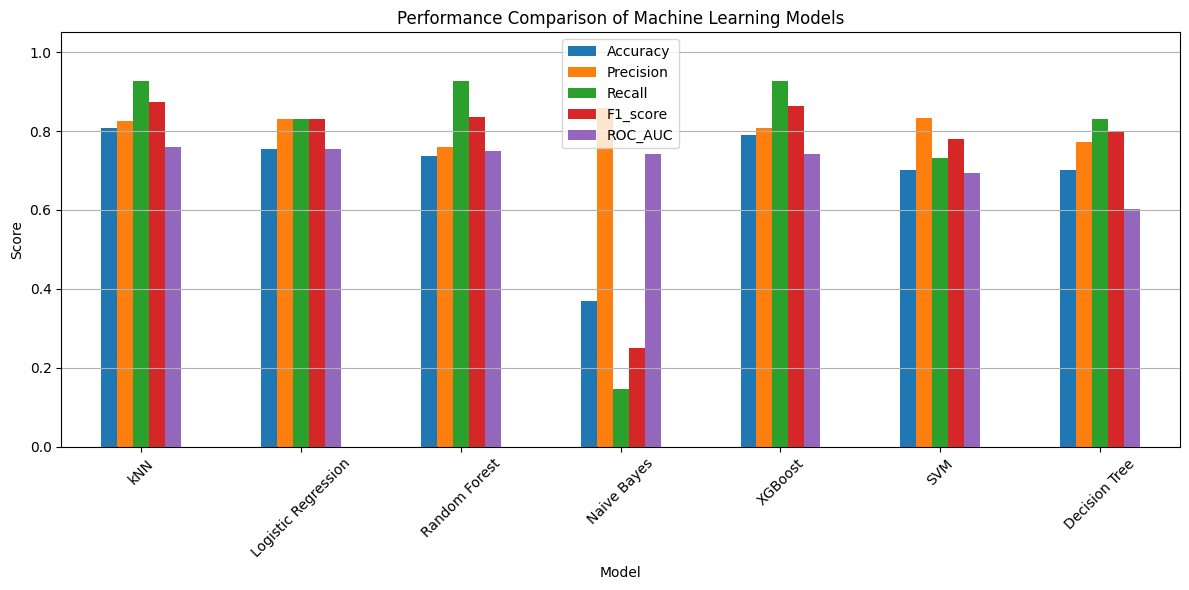

In [83]:
results_df_plot = results_df.set_index("Model")
results_df_plot[["Accuracy","Precision","Recall","F1_score","ROC_AUC"]].plot(
    kind="bar",
    figsize=(12,6)
)
plt.ylabel("Score")
plt.title("Performance Comparison of Machine Learning Models")
plt.xticks(rotation=45)
plt.ylim(0,1.05)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

**Figure 2. ROC Curves**

In [84]:
# Modify the training loop slightly to save probabilities.

roc_results = {}
results = []
for name, model in models.items():
    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    try:
        y_prob = clf.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test,y_prob)
        roc_results[name] = y_prob
    except:
        auc = np.nan
    results.append({
        "Model":name,
        "Accuracy":accuracy_score(y_test,y_pred),
        "Precision":precision_score(y_test,y_pred),
        "Recall":recall_score(y_test,y_pred),
        "F1_score":f1_score(y_test,y_pred),
        "ROC_AUC":auc
    })

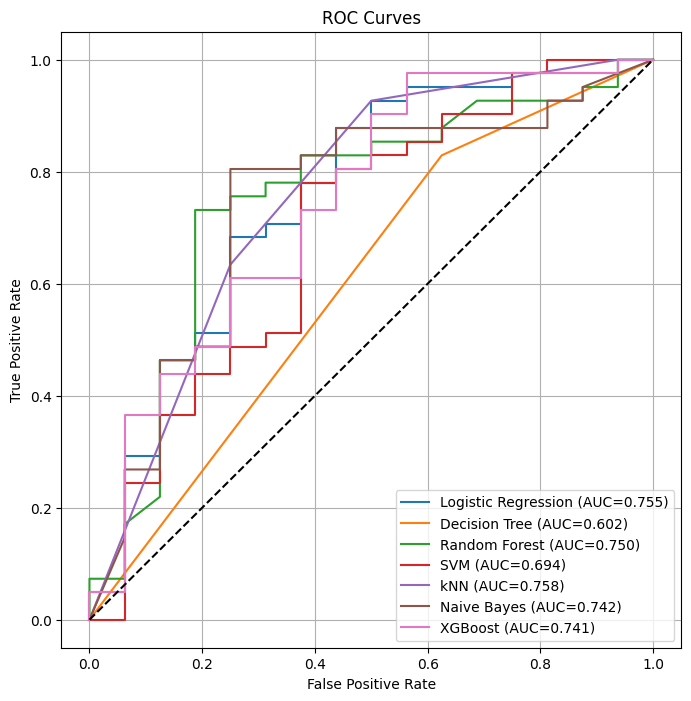

In [85]:
# plot ROC curves

from sklearn.metrics import roc_curve
plt.figure(figsize=(8,8))
for name,y_prob in roc_results.items():
    fpr,tpr,_ = roc_curve(y_test,y_prob)
    auc = roc_auc_score(y_test,y_prob)
    plt.plot(fpr,tpr,label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid()
plt.show()

**Figure 3. Confusion Matrix**

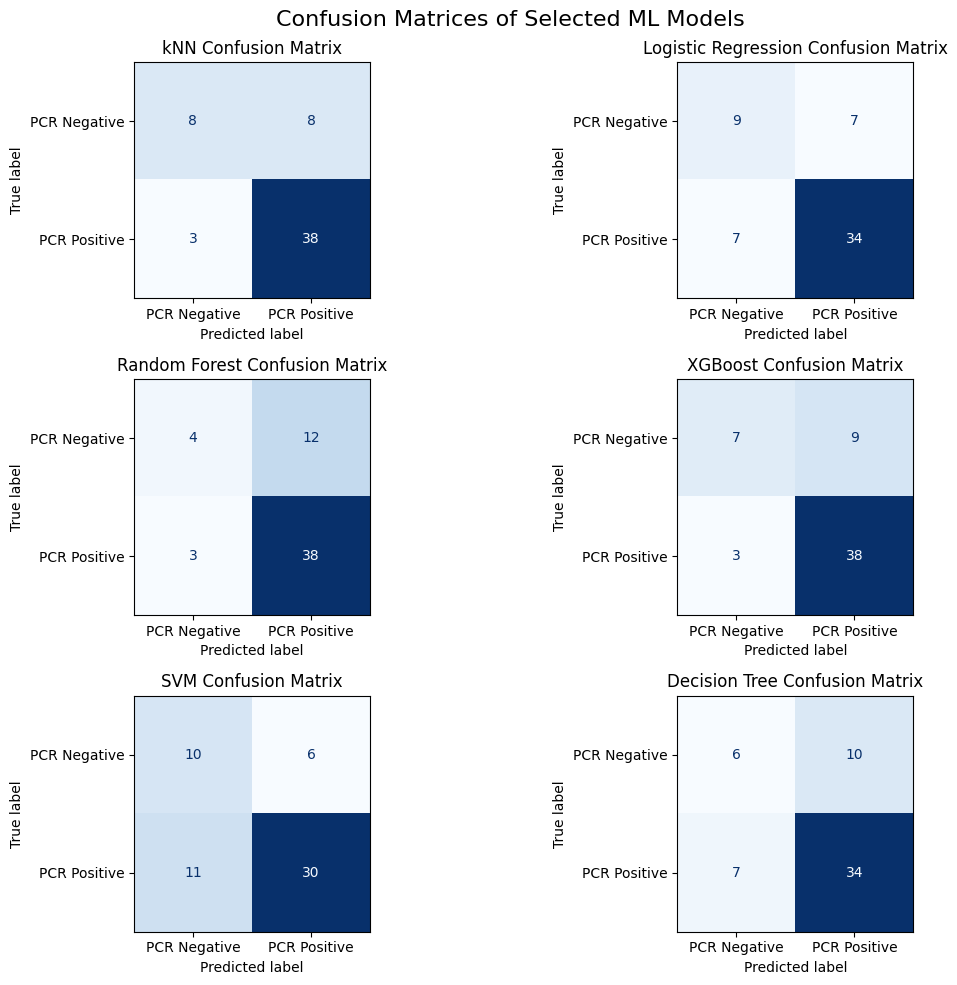

In [101]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models_cm = {
    "kNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
    )
}

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, model) in zip(axes, models_cm.items()):

    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    clf.fit(X_train, y_train)

    ConfusionMatrixDisplay.from_estimator(
        clf,
        X_test,
        y_test,
        display_labels=["PCR Negative", "PCR Positive"],
        cmap="Blues",
        ax=ax,
        colorbar=False
    )

    ax.set_title(f"{name} Confusion Matrix")

plt.suptitle("Confusion Matrices of Selected ML Models", fontsize=16)
plt.tight_layout()
plt.show()

**Figure 4. Precision-Recall Curves**

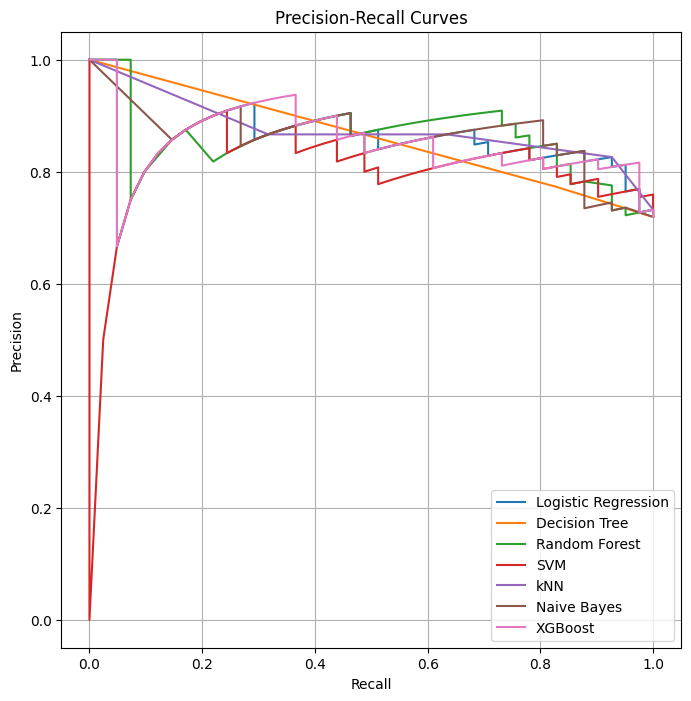

In [102]:
from sklearn.metrics import precision_recall_curve
plt.figure(figsize=(8,8))
for name,y_prob in roc_results.items():
    precision,recall,_ = precision_recall_curve(
        y_test,
        y_prob
    )
    plt.plot(recall,precision,label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid()
plt.show()

**Figure 5. Heatmap of Metrics**

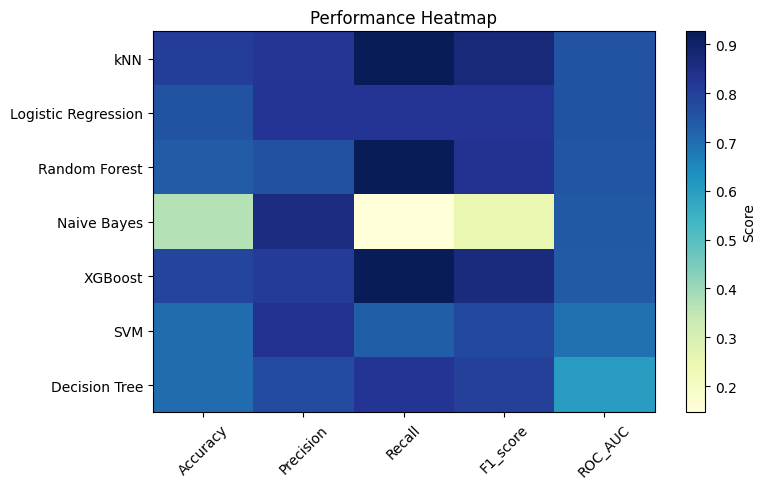

In [103]:
import matplotlib.pyplot as plt
metrics = results_df.set_index("Model")
plt.figure(figsize=(8,5))
plt.imshow(metrics,cmap="YlGnBu",aspect="auto")
plt.colorbar(label="Score")
plt.xticks(range(len(metrics.columns)),metrics.columns,rotation=45)
plt.yticks(range(len(metrics.index)),metrics.index)
plt.title("Performance Heatmap")
plt.tight_layout()
plt.show()

**Figure 6. Feature Importance**


kNN


,Feature_cleaned,Feature_original,Importance,SD
8,platelet_10_9_l,Platelet (10^9/L),0.129497,0.038808
4,pulse,Pulse,0.055335,0.034620
21,egfr,eGFR,0.049886,0.030298
5,temperature_c,Temperature (c),0.040130,0.036978
3,diastolic_blood_pressure,Diastolic Blood Pressure,0.039558,0.029069
7,hemotocrit,Hemotocrit (%),0.035328,0.030542
9,alt_iu_l,ALT (IU/L),0.025915,0.025540
6,respiratory_rate,Respiratory rate,0.018102,0.025548
10,ast_iu_l,AST (IU/L),0.013948,0.010512
1,days_of_fever,Days of Fever,0.012005,0.025685



Random Forest


,Feature_cleaned,Feature_original,Importance,SD
8,platelet_10_9_l,Platelet (10^9/L),0.055907,0.031539
10,ast_iu_l,AST (IU/L),0.018064,0.018512
5,temperature_c,Temperature (c),0.016044,0.024224
7,hemotocrit,Hemotocrit (%),0.015930,0.017608
6,respiratory_rate,Respiratory rate,0.010709,0.007411
13,diabetes,Diabetes,0.009032,0.009892
18,diarrhea,Diarrhea,0.007508,0.005535
0,fever_or_chills,Fever or chills,0.005678,0.009068
21,egfr,eGFR,0.004764,0.025838
14,cardiovascular_disease,Cardiovascular disease,0.003925,0.010454



Logistic Regression


...

,Feature_cleaned,Feature_original,Importance,SD
8,platelet_10_9_l,Platelet (10^9/L),1.418445e-01,0.046228
5,temperature_c,Temperature (c),4.245427e-02,0.033447
7,hemotocrit,Hemotocrit (%),4.192073e-02,0.048040
21,egfr,eGFR,2.606707e-02,0.018068
6,respiratory_rate,Respiratory rate,7.317073e-03,0.007224
10,ast_iu_l,AST (IU/L),6.021341e-03,0.015232
4,pulse,Pulse,2.439024e-03,0.013046
3,diastolic_blood_pressure,Diastolic Blood Pressure,2.210366e-03,0.007506
0,fever_or_chills,Fever or chills,0.000000e+00,0.000000
15,fever,Fever,0.000000e+00,0.000000



SVM


,Feature_cleaned,Feature_original,Importance,SD
8,platelet_10_9_l,Platelet (10^9/L),0.168598,0.048591
5,temperature_c,Temperature (c),0.045579,0.029421
21,egfr,eGFR,0.013720,0.021515
18,diarrhea,Diarrhea,0.007012,0.003102
9,alt_iu_l,ALT (IU/L),0.006326,0.010465
0,fever_or_chills,Fever or chills,0.006098,0.007965
14,cardiovascular_disease,Cardiovascular disease,0.003277,0.007717
10,ast_iu_l,AST (IU/L),0.003277,0.002943
15,fever,Fever,0.001753,0.004503
7,hemotocrit,Hemotocrit (%),0.001601,0.015263



Decision Tree


,Feature_cleaned,Feature_original,Importance,SD
8,platelet_10_9_l,Platelet (10^9/L),0.102896,0.050826
6,respiratory_rate,Respiratory rate,0.041921,0.030352
10,ast_iu_l,AST (IU/L),0.037233,0.029091
1,days_of_fever,Days of Fever,0.020922,0.014610
2,systolic_blood_pressure,Systolic Blood Pressure,0.018140,0.027787
7,hemotocrit,Hemotocrit (%),0.016006,0.025659
3,diastolic_blood_pressure,Diastolic Blood Pressure,0.002515,0.009938
20,rash,Rash,0.000000,0.000000
0,fever_or_chills,Fever or chills,0.000000,0.000000
4,pulse,Pulse,0.000000,0.000000


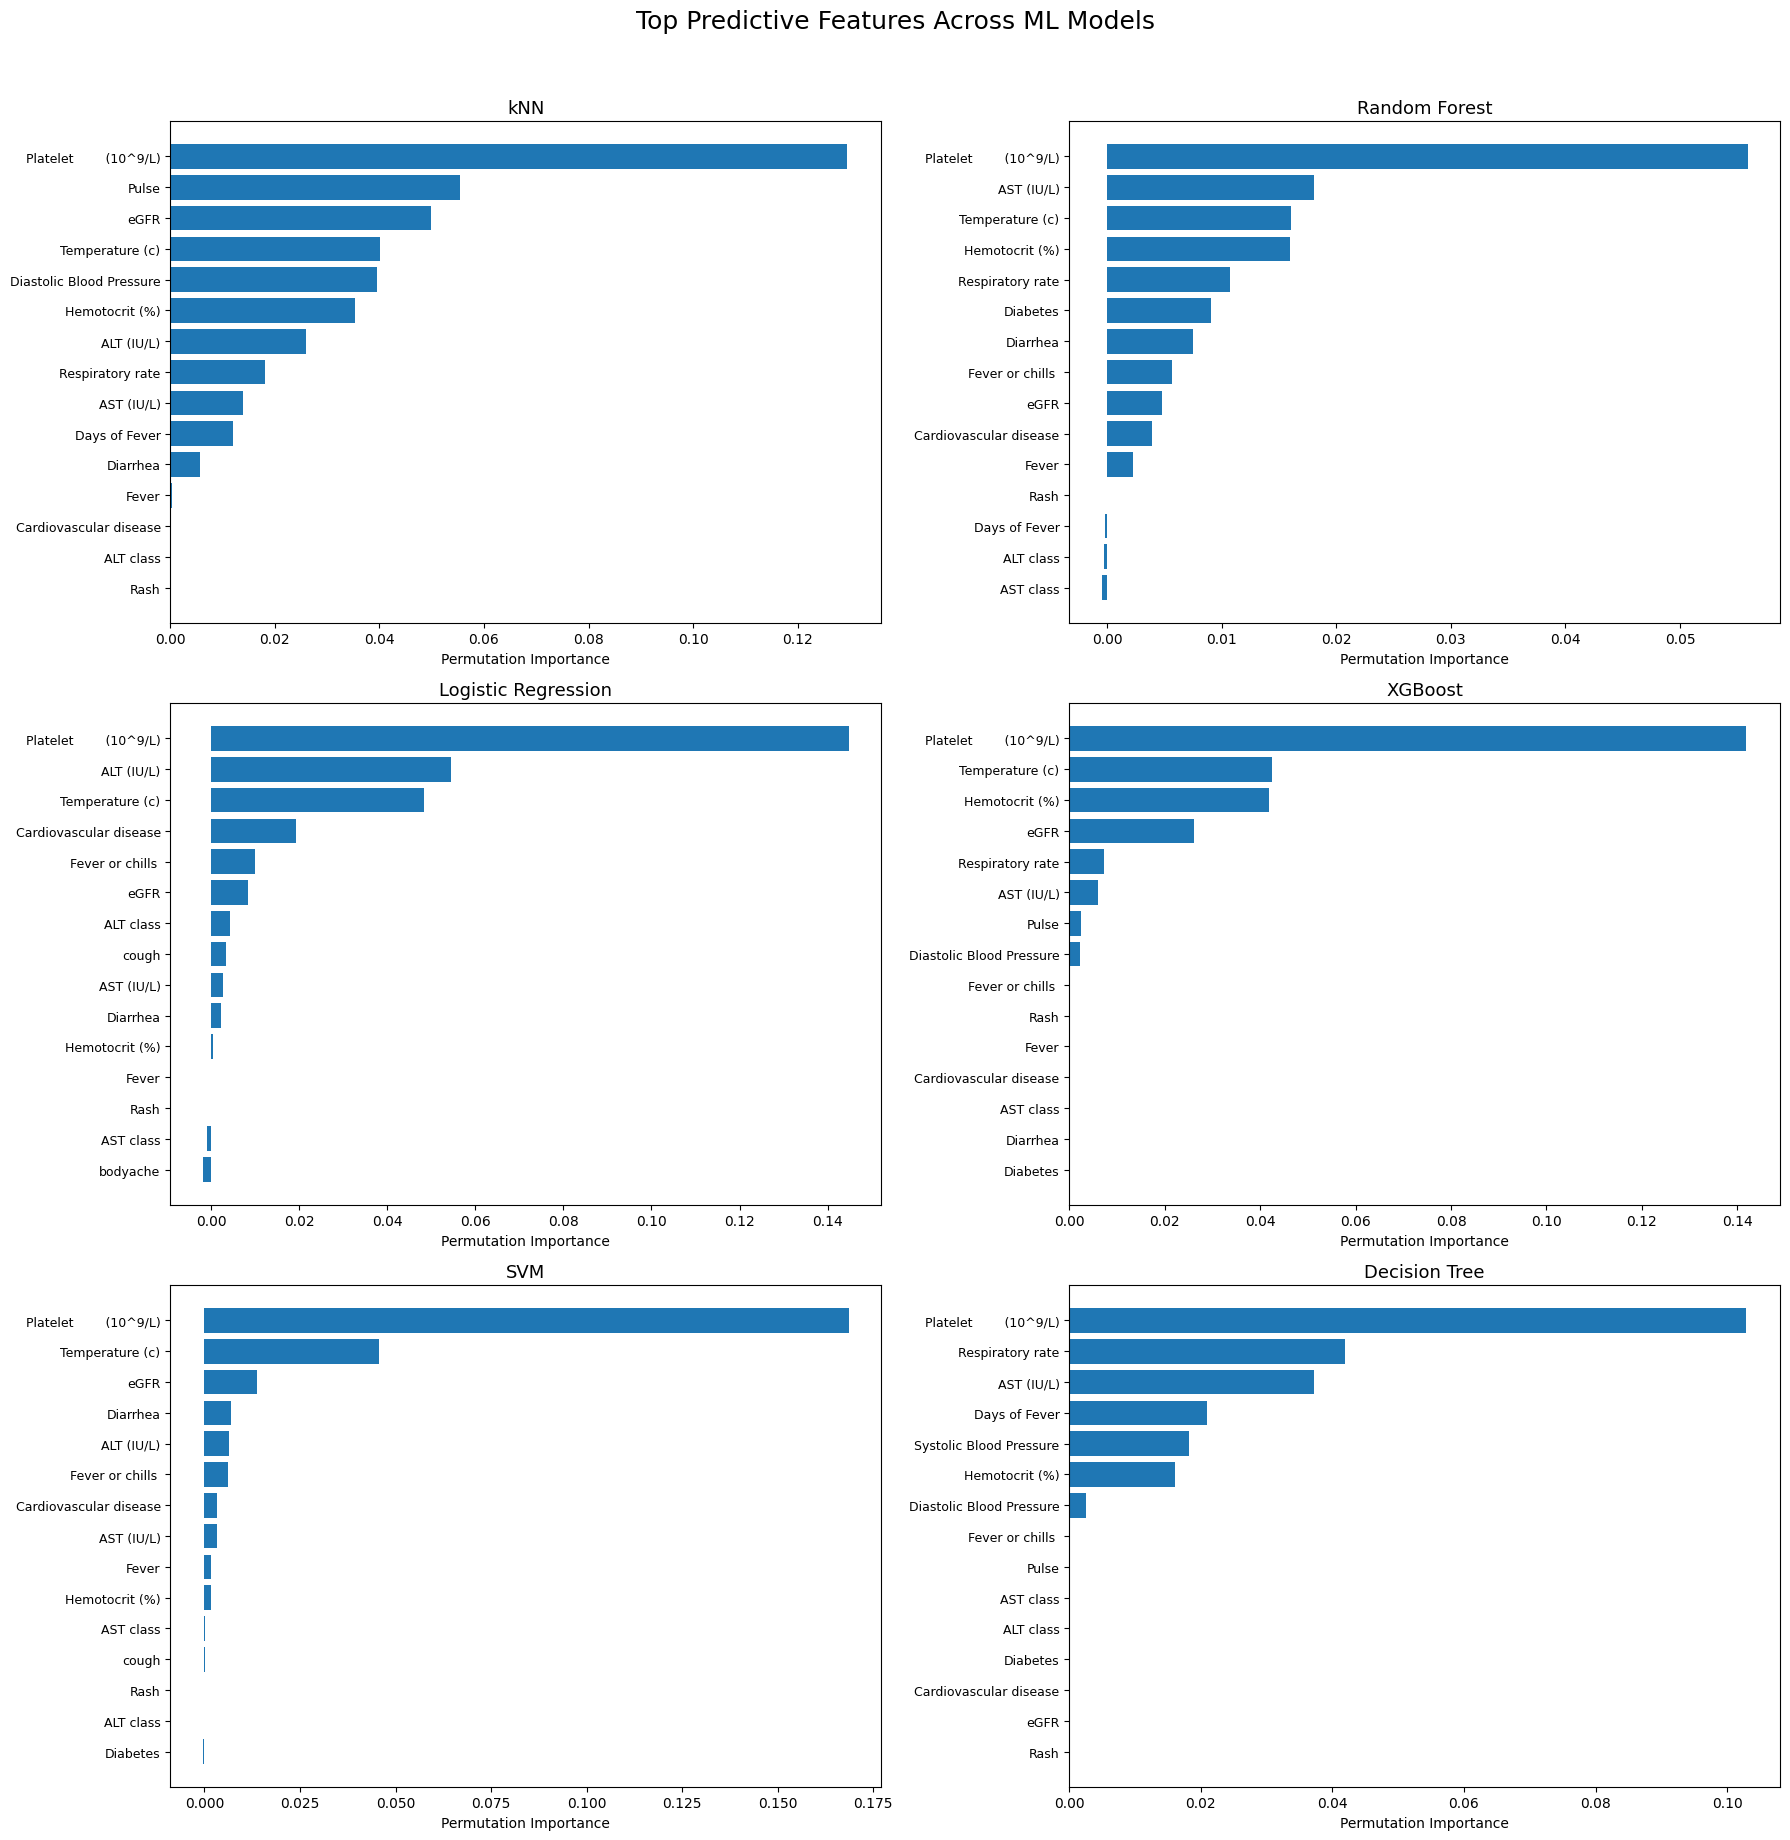

In [108]:
from sklearn.inspection import permutation_importance

# Step 1: Create mapping from cleaned column names back to original Excel column names

cleaned_columns_from_original = (
    pd.Series(original_columns)
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", "_", regex=True)
    .str.replace(r"[^\w]", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
    .tolist()
)

clean_to_original = dict(zip(cleaned_columns_from_original, original_columns))


# Step 2: Define selected models

models_importance = {
    "kNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )
}


# Step 3: Calculate permutation importance

importance_tables = {}

for name, model in models_importance.items():

    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    clf.fit(X_train, y_train)

    result = permutation_importance(
        clf,
        X_test,
        y_test,
        scoring="roc_auc",
        n_repeats=20,
        random_state=42
    )

    importance_df = pd.DataFrame({
        "Feature_cleaned": X_test.columns,
        "Feature_original": [
            clean_to_original.get(col, col) for col in X_test.columns
        ],
        "Importance": result.importances_mean,
        "SD": result.importances_std
    }).sort_values("Importance", ascending=False)

    importance_tables[name] = importance_df

    print("\n" + "="*70)
    print(name)
    print("="*70)
    display(importance_df.head(20))


# Step 4: Plot top 15 features for each model in 3 x 2 format

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.ravel()

for ax, (name, importance_df) in zip(axes, importance_tables.items()):

    top = importance_df.head(15).sort_values("Importance")

    ax.barh(
        top["Feature_original"],
        top["Importance"]
    )

    ax.set_title(name, fontsize=13)
    ax.set_xlabel("Permutation Importance")
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle(
    "Top Predictive Features Across ML Models",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

**Step 17 — Cross-validation**

In [109]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cv_results = []
cv_scores = {}          # <-- Store every fold score

for name, model in models.items():
    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    scores = cross_val_score(
        clf,
        X_fixed,
        y,
        cv=cv,
        scoring="roc_auc"
    )
    cv_scores[name] = scores

    cv_results.append({
        "Model": name,
        "Mean_ROC_AUC": scores.mean(),
        "SD_ROC_AUC": scores.std()
    })

cv_results_df = (
    pd.DataFrame(cv_results)
      .sort_values("Mean_ROC_AUC", ascending=False)
)

cv_results_df

,Model,Mean_ROC_AUC,SD_ROC_AUC
0,Logistic Regression,0.688270,0.056482
2,Random Forest,0.681433,0.073364
3,SVM,0.674627,0.076220
5,Naive Bayes,0.673247,0.108722
6,XGBoost,0.667767,0.102671
4,kNN,0.638956,0.105953
1,Decision Tree,0.576890,0.061037


# **Interpretation:**
**ROC-AUC measures how well a model separates the two outcome classes, in this case DENV PCR-positive and DENV PCR-negative patients. A ROC-AUC of 0.5 indicates performance no better than random guessing, whereas a ROC-AUC of 1.0 indicates perfect discrimination.**


After excluding diagnostic-leakage variables, administrative/date/sample-related columns, and non-preferred variables, five-fold stratified cross-validation showed that Logistic Regression achieved the highest mean ROC-AUC of 0.688 ± 0.056. This was followed by Random Forest with a ROC-AUC of 0.681 ± 0.073 and SVM with 0.675 ± 0.076. These results indicate that the selected routine clinical and laboratory variables contain a measurable but moderate discriminatory signal for predicting DENV qRT-PCR positivity.

Logistic Regression was selected as the preferred model because it achieved the highest cross-validated ROC-AUC, showed relatively low variability across folds, and provides better clinical interpretability compared with more complex models. Random Forest and SVM showed comparable but slightly lower performance, suggesting that nonlinear models did not substantially improve classification. XGBoost also showed moderate performance but did not outperform Logistic Regression, Random Forest, or SVM. Although Naive Bayes achieved a similar mean ROC-AUC, its higher variability and poor classification performance in the test-set evaluation made it less suitable as a final model. kNN performed well in the single train-test split but showed weaker and more variable performance during cross-validation, indicating limited stability. Decision Tree showed the weakest discriminatory ability and was not suitable as a final model.

Overall, these findings suggest that selected clinical and laboratory features can provide useful diagnostic-support information for PCR-confirmed dengue infection, but the performance remains below the level required for standalone diagnosis. Therefore, the model should be interpreted as an exploratory framework for risk stratification or prioritization of molecular testing, rather than a replacement for qRT-PCR confirmation.

**Figure 7. Mean ROC-AUC ± Standard Deviation**

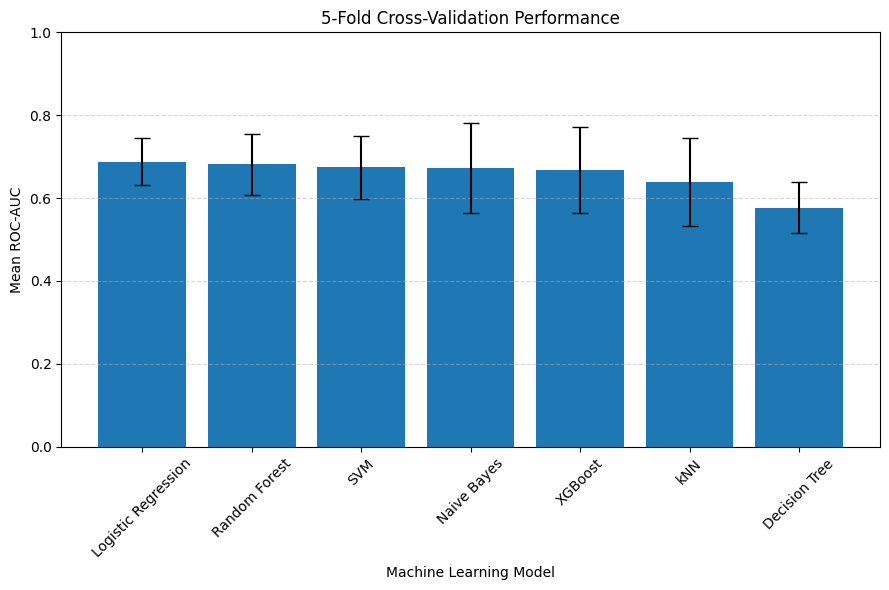

In [110]:
plt.figure(figsize=(9,6))

plt.bar(
    cv_results_df["Model"],
    cv_results_df["Mean_ROC_AUC"],
    yerr=cv_results_df["SD_ROC_AUC"],
    capsize=6
)

plt.ylabel("Mean ROC-AUC")
plt.xlabel("Machine Learning Model")
plt.title("5-Fold Cross-Validation Performance")

plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Figure 8. ROC-AUC Boxplot Across Folds**

Interpretation:

* Smaller box = more stable model.
* Higher median = better model.
* Smaller whiskers = lower variability.

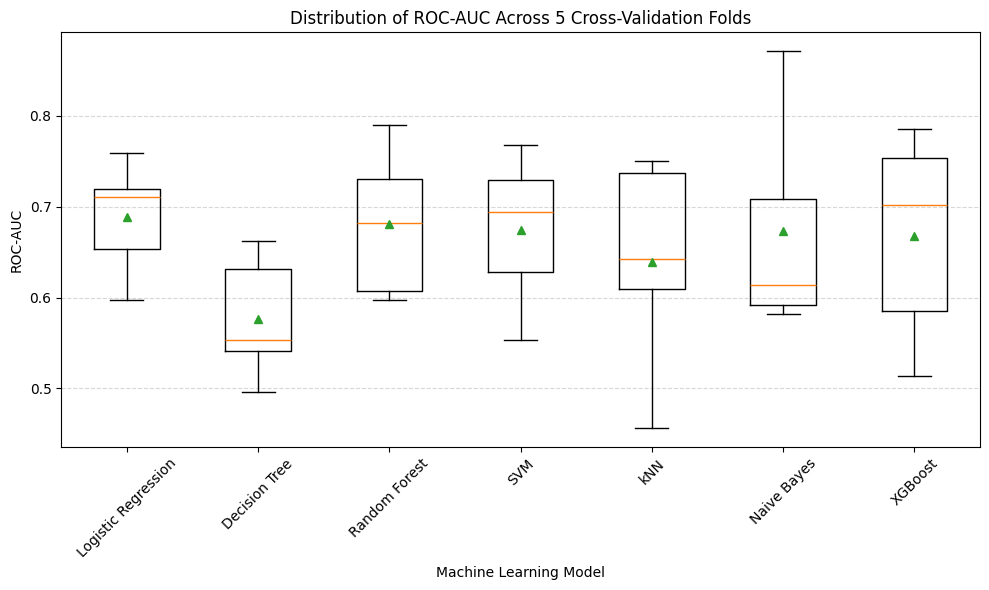

In [112]:
# This shows how stable each model is across the five folds.

plt.figure(figsize=(10,6))
plt.boxplot(
    [cv_scores[m] for m in cv_scores.keys()],
    tick_labels=cv_scores.keys(),
    showmeans=True
)
plt.ylabel("ROC-AUC")
plt.xlabel("Machine Learning Model")
plt.title("Distribution of ROC-AUC Across 5 Cross-Validation Folds")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Figure 9. Model Stability Comparison**

It tells:

* which model has the highest ROC-AUC;
* which model has the smallest standard deviation;
* the trade-off between performance and stability.

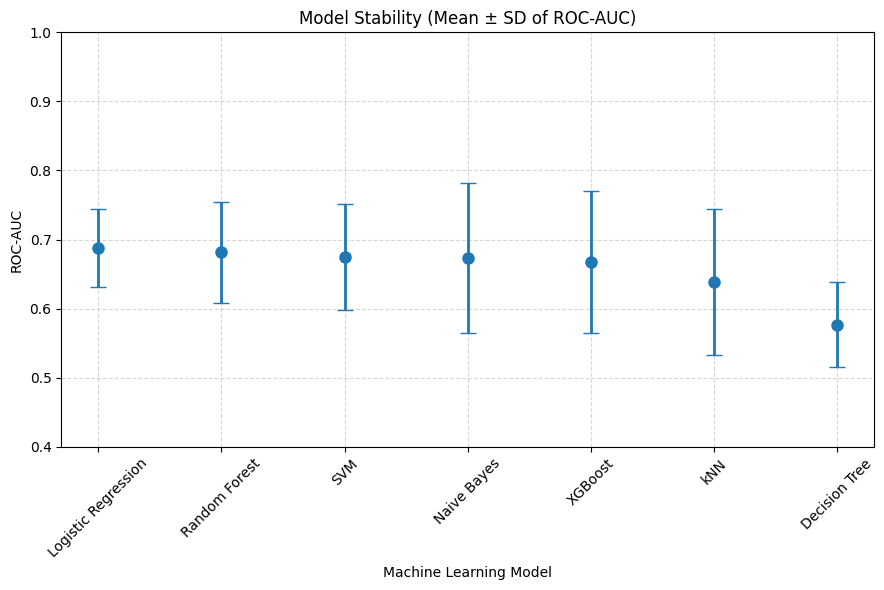

In [113]:
plt.figure(figsize=(9,6))

plt.errorbar(
    cv_results_df["Model"],
    cv_results_df["Mean_ROC_AUC"],
    yerr=cv_results_df["SD_ROC_AUC"],
    fmt="o",
    capsize=6,
    linewidth=2,
    markersize=8
)
plt.ylabel("ROC-AUC")
plt.xlabel("Machine Learning Model")
plt.title("Model Stability (Mean ± SD of ROC-AUC)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.ylim(0.4,1.0)
plt.tight_layout()
plt.show()

**Figure 10. Fold-wise ROC-AUC**

This highlights whether a model performs consistently across folds or has unusually high or low performance in specific folds.

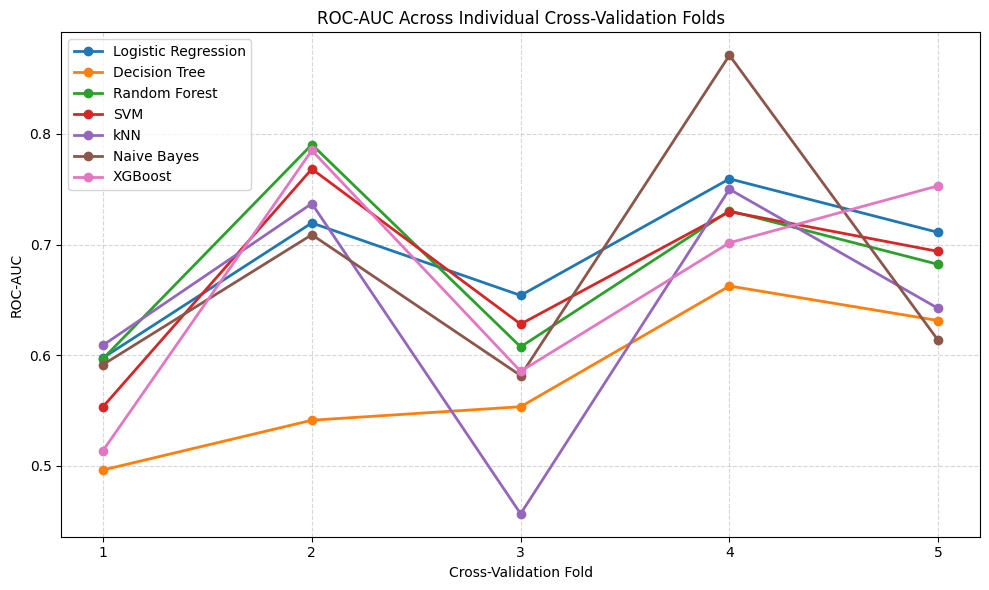

In [114]:
cv_plot = pd.DataFrame(cv_scores)

plt.figure(figsize=(10,6))
for model in cv_plot.columns:
    plt.plot(
        range(1,6),
        cv_plot[model],
        marker="o",
        linewidth=2,
        label=model
    )
plt.xlabel("Cross-Validation Fold")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Across Individual Cross-Validation Folds")
plt.xticks(range(1,6))
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

**Figure 11. Ranked Mean ROC-AUC**

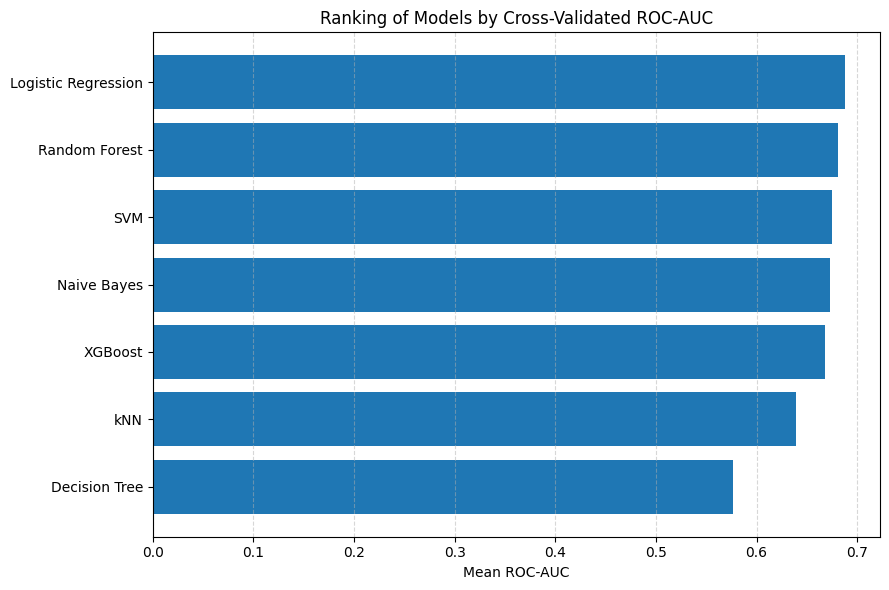

In [131]:
cv_results_df = cv_results_df.sort_values(
    "Mean_ROC_AUC",
    ascending=True
)
plt.figure(figsize=(9,6))
plt.barh(
    cv_results_df["Model"],
    cv_results_df["Mean_ROC_AUC"]
)
plt.xlabel("Mean ROC-AUC")
plt.title("Ranking of Models by Cross-Validated ROC-AUC")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

**Figure 12. PCA analysis: PCR-positive vs PCR-negative**

,Principal_Component,Explained_Variance_Ratio,Explained_Variance_Percent
0,PC1,0.153041,15.304114
1,PC2,0.135267,13.526660
2,PC3,0.101455,10.145511
3,PC4,0.090102,9.010234


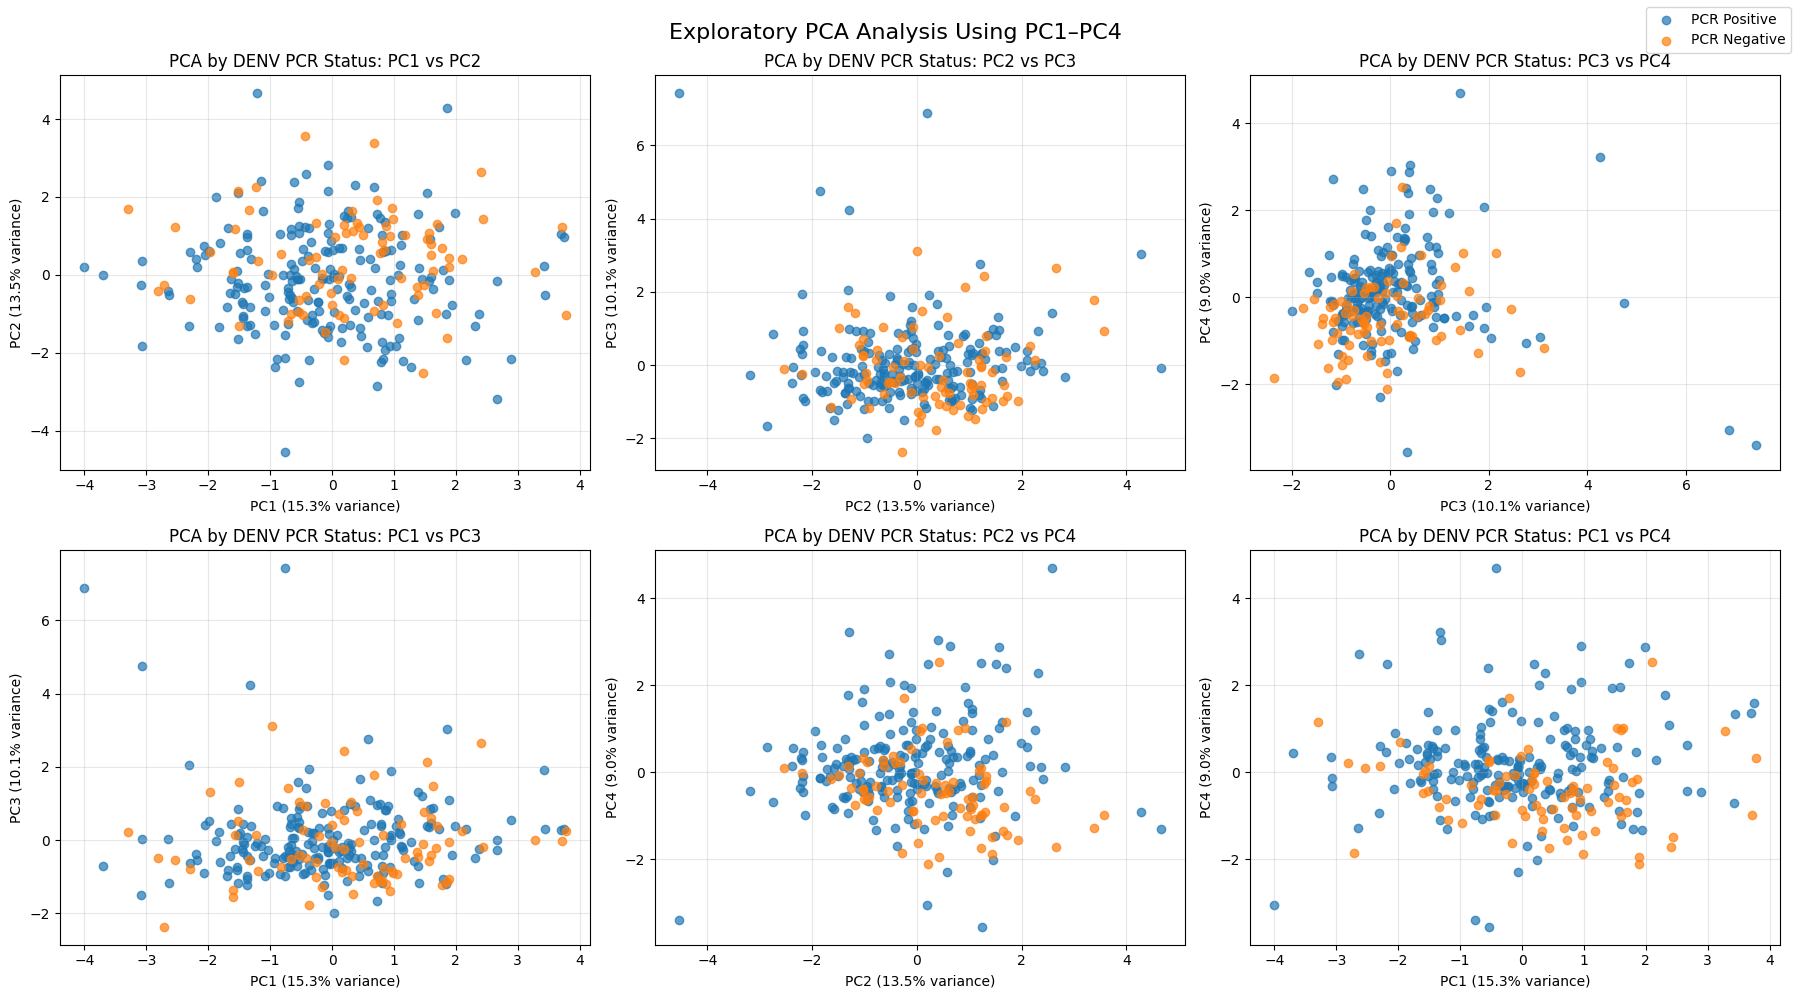

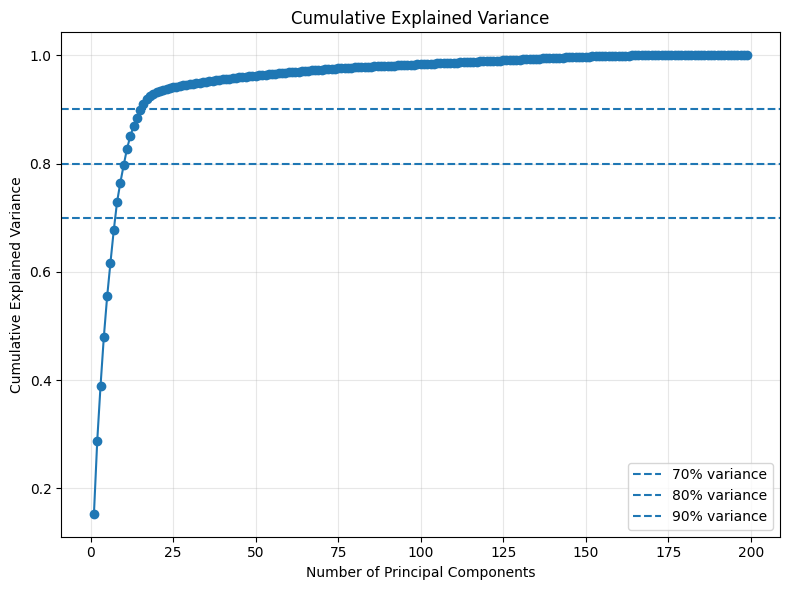

In [130]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# PCA-only dataset: remove study-design variables
# ---------------------------------------------------------

X_pca_clinical = X_fixed.drop(columns=["year", "aim"], errors="ignore")

# Recreate numeric and categorical features for PCA dataset
numeric_features_pca = X_pca_clinical.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_pca = X_pca_clinical.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Build PCA-specific preprocessor
numeric_transformer_pca = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_pca = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_pca = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_pca, numeric_features_pca),
        ("cat", categorical_transformer_pca, categorical_features_pca)
    ],
    sparse_threshold=0
)

# Transform features
X_processed = preprocessor_pca.fit_transform(X_pca_clinical)

# ---------------------------------------------------------
# PCA for PC1–PC4
# ---------------------------------------------------------

pca_4d = PCA(n_components=4, random_state=42)
X_pca_4d = pca_4d.fit_transform(X_processed)

# Full PCA for cumulative explained variance
pca_full = PCA()
pca_full.fit(X_processed)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# PCA dataframe with PC1–PC4
pca_df = pd.DataFrame({
    "PC1": X_pca_4d[:, 0],
    "PC2": X_pca_4d[:, 1],
    "PC3": X_pca_4d[:, 2],
    "PC4": X_pca_4d[:, 3],
    "PCR_status": y.map({
        0: "PCR Negative",
        1: "PCR Positive"
    })
})

# Display explained variance for PC1–PC4
variance_df = pd.DataFrame({
    "Principal_Component": ["PC1", "PC2", "PC3", "PC4"],
    "Explained_Variance_Ratio": pca_4d.explained_variance_ratio_,
    "Explained_Variance_Percent": pca_4d.explained_variance_ratio_ * 100
})

display(variance_df)

# ---------------------------------------------------------
# PCA scatter plots using PC1–PC4
# ---------------------------------------------------------

pc_pairs = [
    ("PC1", "PC2"),
    ("PC2", "PC3"),
    ("PC3", "PC4"),
    ("PC1", "PC3"),
    ("PC2", "PC4"),
    ("PC1", "PC4")
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, (pc_x, pc_y) in zip(axes, pc_pairs):

    for status in pca_df["PCR_status"].unique():
        subset = pca_df[pca_df["PCR_status"] == status]

        ax.scatter(
            subset[pc_x],
            subset[pc_y],
            label=status,
            alpha=0.7
        )

    pc_x_index = int(pc_x.replace("PC", "")) - 1
    pc_y_index = int(pc_y.replace("PC", "")) - 1

    ax.set_xlabel(
        f"{pc_x} ({pca_4d.explained_variance_ratio_[pc_x_index]*100:.1f}% variance)"
    )

    ax.set_ylabel(
        f"{pc_y} ({pca_4d.explained_variance_ratio_[pc_y_index]*100:.1f}% variance)"
    )

    ax.set_title(f"PCA by DENV PCR Status: {pc_x} vs {pc_y}")
    ax.grid(alpha=0.3)

# Add one shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right"
)

plt.suptitle(
    "Exploratory PCA Analysis Using PC1–PC4",
    fontsize=16
)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Cumulative explained variance plot
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(y=0.70, linestyle="--", label="70% variance")
plt.axhline(y=0.80, linestyle="--", label="80% variance")
plt.axhline(y=0.90, linestyle="--", label="90% variance")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [132]:
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# PCA with 4 components
# ---------------------------------------------------------

X_processed_pca = preprocessor_pca.fit_transform(X_fixed)

pca_4d = PCA(n_components=4)

X_pca_4d = pca_4d.fit_transform(X_processed_pca)

print("Explained variance ratio:")
print(pca_4d.explained_variance_ratio_)

print("Explained variance percentage:")
print(pca_4d.explained_variance_ratio_ * 100)

Explained variance ratio:
[0.15304114 0.1352666  0.10145511 0.09010234]
Explained variance percentage:
[15.30411373 13.52666008 10.14551127  9.01023408]


In [133]:
# ---------------------------------------------------------
# PCA loading table with original Excel column names: PC1–PC4
# ---------------------------------------------------------

feature_names_pca = preprocessor_pca.get_feature_names_out()

loadings_df = pd.DataFrame(
    pca_4d.components_.T,
    columns=["PC1_loading", "PC2_loading", "PC3_loading", "PC4_loading"],
    index=feature_names_pca
)

# Convert preprocessed feature names back to cleaned/raw feature names
def extract_original_feature_name(feature_name):
    feature_name = feature_name.replace("num__", "").replace("cat__", "")

    for col in X.columns:
        if feature_name == col or feature_name.startswith(col + "_"):
            return col

    return feature_name

loadings_df["Feature_cleaned"] = [
    extract_original_feature_name(f) for f in loadings_df.index
]

loadings_df["Feature_original"] = [
    clean_to_original.get(col, col) for col in loadings_df["Feature_cleaned"]
]

# Absolute loading values
loadings_df["PC1_abs"] = loadings_df["PC1_loading"].abs()
loadings_df["PC2_abs"] = loadings_df["PC2_loading"].abs()
loadings_df["PC3_abs"] = loadings_df["PC3_loading"].abs()
loadings_df["PC4_abs"] = loadings_df["PC4_loading"].abs()

# Keep only useful columns
loadings_df = loadings_df[
    [
        "Feature_original",
        "PC1_loading",
        "PC2_loading",
        "PC3_loading",
        "PC4_loading",
        "PC1_abs",
        "PC2_abs",
        "PC3_abs",
        "PC4_abs"
    ]
]

print("Top contributors to PC1:")
display(
    loadings_df
    .sort_values("PC1_abs", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print("Top contributors to PC2:")
display(
    loadings_df
    .sort_values("PC2_abs", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print("Top contributors to PC3:")
display(
    loadings_df
    .sort_values("PC3_abs", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print("Top contributors to PC4:")
display(
    loadings_df
    .sort_values("PC4_abs", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

Top contributors to PC1:


,Feature_original,PC1_loading,PC2_loading,PC3_loading,PC4_loading,PC1_abs,PC2_abs,PC3_abs,PC4_abs
0,Diastolic Blood Pressure,0.544050,-0.328504,0.002874,-0.147958,0.544050,0.328504,0.002874,0.147958
1,Systolic Blood Pressure,0.538167,-0.342309,0.060713,-0.025199,0.538167,0.342309,0.060713,0.025199
2,Hemotocrit (%),0.383496,-0.159190,-0.234824,0.173057,0.383496,0.159190,0.234824,0.173057
3,Pulse,0.299860,0.369413,0.402653,0.082914,0.299860,0.369413,0.402653,0.082914
4,Platelet (10^9/L),0.246061,0.474682,-0.040126,-0.363589,0.246061,0.474682,0.040126,0.363589
5,Respiratory rate,0.217646,0.428017,0.292437,-0.136484,0.217646,0.428017,0.292437,0.136484
6,Temperature (c),0.138854,0.215426,0.141153,0.802832,0.138854,0.215426,0.141153,0.802832
7,AST (IU/L),-0.118804,-0.202704,0.506618,-0.265393,0.118804,0.202704,0.506618,0.265393
8,Days of Fever,-0.098464,-0.282458,0.625589,0.050142,0.098464,0.282458,0.625589,0.050142
9,eGFR,0.084129,0.118225,-0.089149,-0.120027,0.084129,0.118225,0.089149,0.120027


Top contributors to PC2:


,Feature_original,PC1_loading,PC2_loading,PC3_loading,PC4_loading,PC1_abs,PC2_abs,PC3_abs,PC4_abs
0,Platelet (10^9/L),0.246061,0.474682,-0.040126,-0.363589,0.246061,0.474682,0.040126,0.363589
1,Respiratory rate,0.217646,0.428017,0.292437,-0.136484,0.217646,0.428017,0.292437,0.136484
2,Pulse,0.299860,0.369413,0.402653,0.082914,0.299860,0.369413,0.402653,0.082914
3,Systolic Blood Pressure,0.538167,-0.342309,0.060713,-0.025199,0.538167,0.342309,0.060713,0.025199
4,Diastolic Blood Pressure,0.544050,-0.328504,0.002874,-0.147958,0.544050,0.328504,0.002874,0.147958
5,Days of Fever,-0.098464,-0.282458,0.625589,0.050142,0.098464,0.282458,0.625589,0.050142
6,Temperature (c),0.138854,0.215426,0.141153,0.802832,0.138854,0.215426,0.141153,0.802832
7,AST (IU/L),-0.118804,-0.202704,0.506618,-0.265393,0.118804,0.202704,0.506618,0.265393
8,Hemotocrit (%),0.383496,-0.159190,-0.234824,0.173057,0.383496,0.159190,0.234824,0.173057
9,eGFR,0.084129,0.118225,-0.089149,-0.120027,0.084129,0.118225,0.089149,0.120027


Top contributors to PC3:


,Feature_original,PC1_loading,PC2_loading,PC3_loading,PC4_loading,PC1_abs,PC2_abs,PC3_abs,PC4_abs
0,Days of Fever,-0.098464,-0.282458,0.625589,0.050142,0.098464,0.282458,0.625589,0.050142
1,AST (IU/L),-0.118804,-0.202704,0.506618,-0.265393,0.118804,0.202704,0.506618,0.265393
2,Pulse,0.299860,0.369413,0.402653,0.082914,0.299860,0.369413,0.402653,0.082914
3,Respiratory rate,0.217646,0.428017,0.292437,-0.136484,0.217646,0.428017,0.292437,0.136484
4,Hemotocrit (%),0.383496,-0.159190,-0.234824,0.173057,0.383496,0.159190,0.234824,0.173057
5,Temperature (c),0.138854,0.215426,0.141153,0.802832,0.138854,0.215426,0.141153,0.802832
6,eGFR,0.084129,0.118225,-0.089149,-0.120027,0.084129,0.118225,0.089149,0.120027
7,ALT (IU/L),0.079764,0.070993,-0.074360,-0.055984,0.079764,0.070993,0.074360,0.055984
8,eGFR,-0.070245,-0.095408,0.062155,0.128558,0.070245,0.095408,0.062155,0.128558
9,Systolic Blood Pressure,0.538167,-0.342309,0.060713,-0.025199,0.538167,0.342309,0.060713,0.025199


Top contributors to PC4:


,Feature_original,PC1_loading,PC2_loading,PC3_loading,PC4_loading,PC1_abs,PC2_abs,PC3_abs,PC4_abs
0,Temperature (c),0.138854,0.215426,0.141153,0.802832,0.138854,0.215426,0.141153,0.802832
1,Platelet (10^9/L),0.246061,0.474682,-0.040126,-0.363589,0.246061,0.474682,0.040126,0.363589
2,AST (IU/L),-0.118804,-0.202704,0.506618,-0.265393,0.118804,0.202704,0.506618,0.265393
3,Hemotocrit (%),0.383496,-0.159190,-0.234824,0.173057,0.383496,0.159190,0.234824,0.173057
4,Diastolic Blood Pressure,0.544050,-0.328504,0.002874,-0.147958,0.544050,0.328504,0.002874,0.147958
5,Respiratory rate,0.217646,0.428017,0.292437,-0.136484,0.217646,0.428017,0.292437,0.136484
6,eGFR,-0.070245,-0.095408,0.062155,0.128558,0.070245,0.095408,0.062155,0.128558
7,eGFR,0.084129,0.118225,-0.089149,-0.120027,0.084129,0.118225,0.089149,0.120027
8,bodyache,-0.025274,0.037731,-0.011443,-0.115189,0.025274,0.037731,0.011443,0.115189
9,bodyache,0.025274,-0.037731,0.011443,0.115189,0.025274,0.037731,0.011443,0.115189


After performing five-fold stratified cross-validation, the clinical-feature model showed moderate but not strong discriminatory ability for predicting DENV PCR positivity. Logistic Regression achieved the highest mean ROC-AUC of 0.688 ± 0.056, followed closely by Random Forest (0.681 ± 0.073) and SVM (0.675 ± 0.076). These values indicate that the selected clinical and laboratory variables can separate PCR-positive from PCR-negative patients better than random chance, but the performance is still below the level expected for a reliable standalone diagnostic model. The small performance difference among Logistic Regression, Random Forest, and SVM suggests that no model was overwhelmingly superior. However, Logistic Regression appears to be the most appropriate final model because it achieved the highest cross-validated ROC-AUC, showed relatively low variability across folds, and is easier to interpret clinically.

The model-comparison plots further support this interpretation. Most models clustered around ROC-AUC values of approximately 0.65–0.69, confirming that the dataset contains a real but limited diagnostic signal. The boxplot and fold-wise ROC-AUC results show that model performance varied across folds, particularly for Naive Bayes, XGBoost, and kNN, which showed higher instability. Logistic Regression remained comparatively consistent, whereas Decision Tree showed the weakest performance, with a mean ROC-AUC of 0.577, close to random classification. This suggests that a single decision tree is not suitable for capturing the multivariable clinical pattern associated with DENV PCR positivity.

The PCA results provide an important biological explanation for the moderate ML performance. The first two principal components explained only a limited proportion of the total variance, and the PCR-positive and PCR-negative patients showed substantial overlap in the PCA space. This means that the two groups are not naturally separated by a simple two-dimensional clinical/laboratory pattern. Instead, the relevant clinical information appears to be distributed across multiple variables, which explains why supervised ML models achieved only moderate ROC-AUC values rather than high diagnostic accuracy.

The PCA loading analysis showed that PC1 was mainly driven by blood pressure and hematological/vital-sign variables, especially diastolic blood pressure, systolic blood pressure, hematocrit, pulse, platelet count, respiratory rate, temperature, AST, and days of fever. This suggests that PC1 represents a broad hemodynamic and hematological axis. In other words, the largest source of variation among patients was related to differences in blood pressure, hematocrit, platelet count, pulse, respiratory rate, and general physiological status.

PC2 was mainly influenced by platelet count, respiratory rate, pulse, blood pressure, days of fever, temperature, AST, and hematocrit. Platelet count, respiratory rate, pulse, and temperature loaded positively on PC2, whereas blood pressure, days of fever, AST, and hematocrit loaded in the opposite direction. This suggests that PC2 represents a second clinical axis related to platelet/vital-sign variation opposed to illness duration, liver-enzyme changes, and hemodynamic features. These are biologically meaningful variables in dengue-like illness because platelet count, hematocrit, fever duration, temperature, and AST are commonly linked with dengue clinical presentation and disease physiology.

Overall, PCA suggests that the major variation among patients is driven mainly by blood pressure, platelet count, hematocrit, pulse, respiratory rate, temperature, AST, days of fever, and eGFR. These findings support the ML results by showing that the dataset contains a meaningful clinical and laboratory structure. However, PCA is an unsupervised method, meaning it does not use PCR-positive or PCR-negative labels during analysis. Therefore, PCA should not be interpreted as identifying the strongest predictors of DENV PCR positivity. A variable may contribute strongly to PCA because it explains overall variation in the dataset, but that does not necessarily mean it is the best predictor of PCR status.

# **Thank you**


---


If you reached till here... You should celebrate